In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/financial_performance.csv")

In [6]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Company                 24 non-null     str    
 1   Quarter                 24 non-null     str    
 2   Transaction_Value       24 non-null     int64  
 3   Adjusted_Revenue        24 non-null     int64  
 4   MTU                     24 non-null     float64
 5   Contribution_Margin     24 non-null     float64
 6   Adjusted_EBITDA_Margin  24 non-null     float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.4 KB


In [7]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nObservations by company:")
print(df["Company"].value_counts())
print("\nQuarters:")
print(df["Quarter"].unique())

Shape: (24, 7)

Missing values:
Company                   0
Quarter                   0
Transaction_Value         0
Adjusted_Revenue          0
MTU                       0
Contribution_Margin       0
Adjusted_EBITDA_Margin    0
dtype: int64

Duplicate rows: 0

Observations by company:
Company
Swiggy    12
Zomato    12
Name: count, dtype: int64

Quarters:
<StringArray>
['Q1 FY24', 'Q2 FY24', 'Q3 FY24', 'Q4 FY24', 'Q1 FY25', 'Q2 FY25', 'Q3 FY25',
 'Q4 FY25', 'Q1 FY26', 'Q2 FY26', 'Q3 FY26', 'Q4 FY26']
Length: 12, dtype: str


## Business Question 1:
How has Food Delivery transaction value evolved for Zomato versus Swiggy from FY24 to FY26?

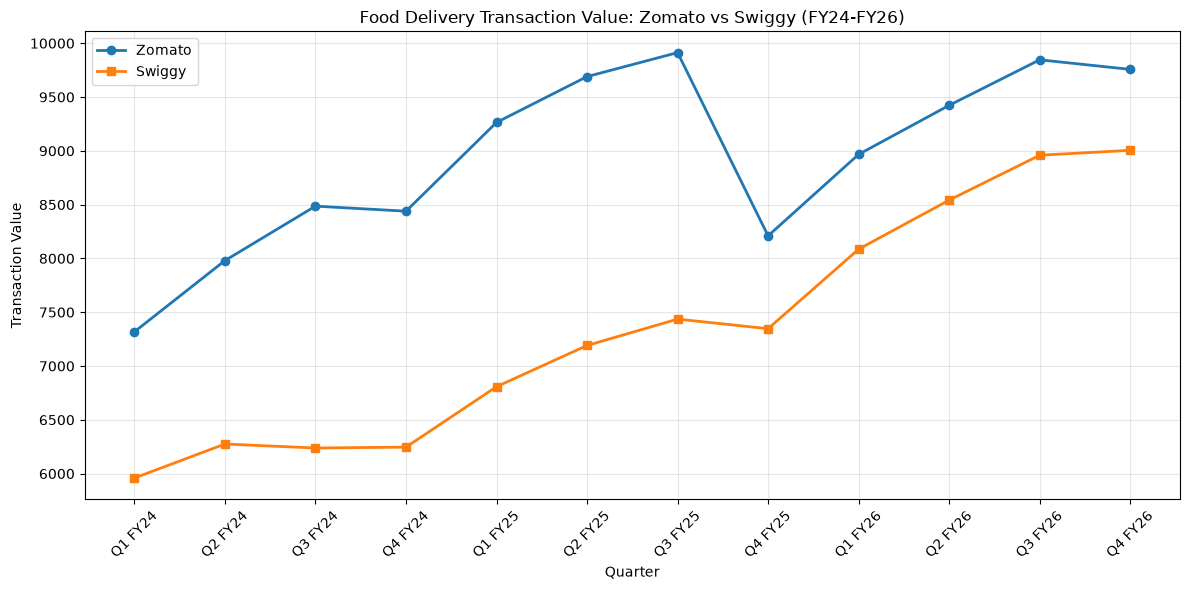

In [8]:
# Filter data for Zomato and Swiggy
zomato_data = df[df['Company'] == 'Zomato']
swiggy_data = df[df['Company'] == 'Swiggy']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(zomato_data['Quarter'], zomato_data['Transaction_Value'], marker='o', label='Zomato', linewidth=2)
plt.plot(swiggy_data['Quarter'], swiggy_data['Transaction_Value'], marker='s', label='Swiggy', linewidth=2)

plt.xlabel('Quarter')
plt.ylabel('Transaction Value')
plt.title('Food Delivery Transaction Value: Zomato vs Swiggy (FY24-FY26)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Q. Which company has the higher transaction value throughout most of the period?
Zomato

#### Q. Is the gap between them getting smaller or larger?
smaller

#### Q. What happens around Q4 FY25?
Zomato's transaction value dips 

#### Q. By Q4 FY26, how close are they?
By 800

# Q. Business Question 2:
How quickly is each company's transaction value growing?

In [9]:
# Calculate YoY percentage change in Transaction Value
df['Transaction_Value_YoY'] = df.groupby('Company')['Transaction_Value'].pct_change(4) * 100

In [10]:
print(df[["Company", "Quarter", "Transaction_Value", "Transaction_Value_YoY"]])

   Company  Quarter  Transaction_Value  Transaction_Value_YoY
0   Swiggy  Q1 FY24               5959                    NaN
1   Swiggy  Q2 FY24               6275                    NaN
2   Swiggy  Q3 FY24               6238                    NaN
3   Swiggy  Q4 FY24               6246                    NaN
4   Swiggy  Q1 FY25               6808              14.247357
5   Swiggy  Q2 FY25               7191              14.597610
6   Swiggy  Q3 FY25               7436              19.204873
7   Swiggy  Q4 FY25               7347              17.627281
8   Swiggy  Q1 FY26               8086              18.772033
9   Swiggy  Q2 FY26               8542              18.787373
10  Swiggy  Q3 FY26               8959              20.481442
11  Swiggy  Q4 FY26               9005              22.567034
12  Zomato  Q1 FY24               7318                    NaN
13  Zomato  Q2 FY24               7980                    NaN
14  Zomato  Q3 FY24               8486                    NaN
15  Zoma

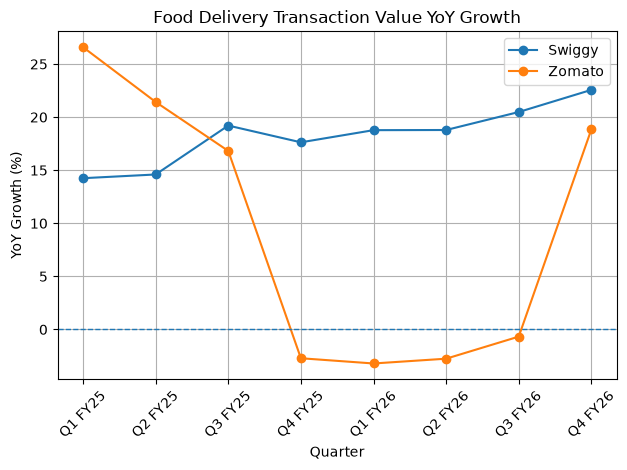

In [11]:
growth_df = df.dropna(subset=["Transaction_Value_YoY"])

for company in growth_df["Company"].unique():
    company_data = growth_df[growth_df["Company"] == company]

    plt.plot(
        company_data["Quarter"],
        company_data["Transaction_Value_YoY"],
        marker="o",
        label=company
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Food Delivery Transaction Value YoY Growth")
plt.xlabel("Quarter")
plt.ylabel("YoY Growth (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1. Swiggy is growing faster.
2. The narrowing of the transaction values between zomato & swiggy is due to both contracting YoY of Zomato and consistent growth of Swiggy.

## Business Question 3:
What is driving the growth?

In [12]:
df["MTU_YoY"] = (
    df.groupby("Company")["MTU"]
      .pct_change(periods=4) * 100
)

In [13]:
df[["Company", "Quarter", "MTU", "MTU_YoY"]]

,Company,Quarter,MTU,MTU_YoY
0,Swiggy,Q1 FY24,12.6,NaN
1,Swiggy,Q2 FY24,12.9,NaN
2,Swiggy,Q3 FY24,12.5,NaN
3,Swiggy,Q4 FY24,12.9,NaN
4,Swiggy,Q1 FY25,14.0,11.111111
5,Swiggy,Q2 FY25,14.7,13.953488
6,Swiggy,Q3 FY25,14.9,19.200000
7,Swiggy,Q4 FY25,15.1,17.054264
8,Swiggy,Q1 FY26,16.3,16.428571
9,Swiggy,Q2 FY26,17.2,17.006803


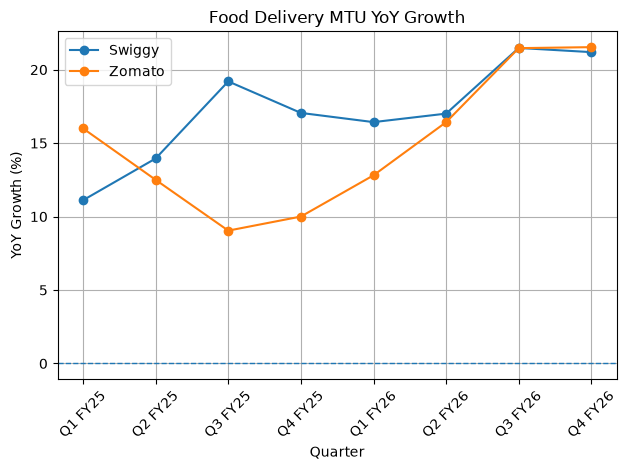

In [14]:
mtu_df = df.dropna(subset=["MTU_YoY"])

for company in mtu_df["Company"].unique():
    company_data = mtu_df[mtu_df["Company"] == company]

    plt.plot(
        company_data["Quarter"],
        company_data["MTU_YoY"],
        marker="o",
        label=company
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Food Delivery MTU YoY Growth")
plt.xlabel("Quarter")
plt.ylabel("YoY Growth (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Swiggy maintained stronger and more consistent MTU growth through much of FY25–FY26, while Zomato's MTU growth declined during FY25 before recovering strongly in FY26. By Q3 FY26, both companies had reached roughly 21–22% YoY MTU growth.

## Business Question 4: Transaction Value vs MTU Growth
Across the 16 comparable YoY observations, is higher MTU growth associated with higher transaction-value growth?

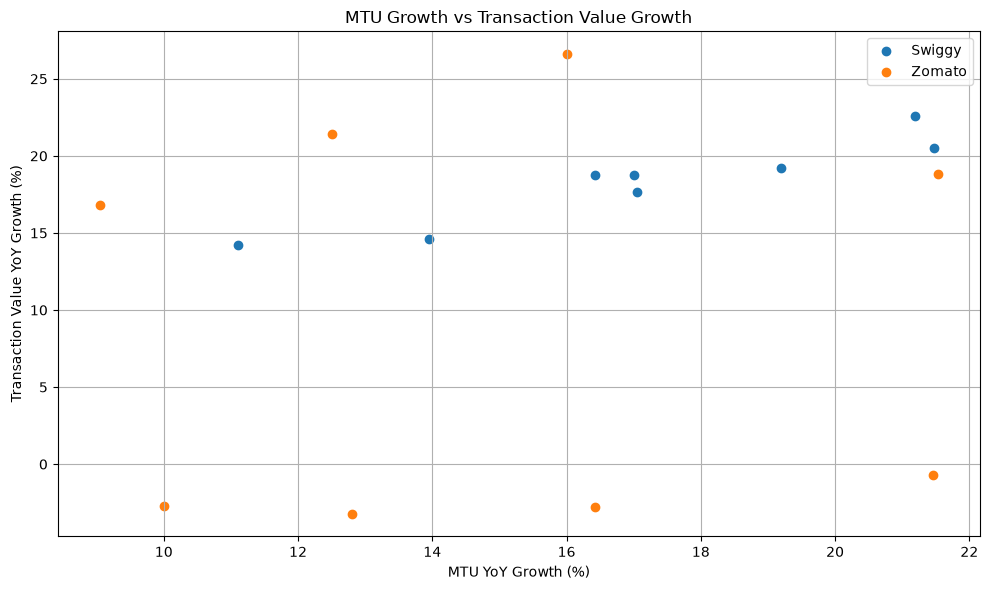

In [15]:
plt.figure(figsize=(10, 6))

for company in df["Company"].unique():
    company_data = df[
        (df["Company"] == company) &
        (df["Transaction_Value_YoY"].notna()) &
        (df["MTU_YoY"].notna())
    ]

    plt.scatter(
        company_data["MTU_YoY"],
        company_data["Transaction_Value_YoY"],
        label=company
    )

plt.xlabel("MTU YoY Growth (%)")
plt.ylabel("Transaction Value YoY Growth (%)")
plt.title("MTU Growth vs Transaction Value Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
print(
    df.groupby("Company")[["MTU_YoY", "Transaction_Value_YoY"]]
      .corr()
)

                                MTU_YoY  Transaction_Value_YoY
Company                                                       
Swiggy  MTU_YoY                1.000000               0.936740
        Transaction_Value_YoY  0.936740               1.000000
Zomato  MTU_YoY                1.000000               0.024299
        Transaction_Value_YoY  0.024299               1.000000


Swiggy's transaction-value growth appears closely associated with expansion in its transacting user base, whereas Zomato's transaction-value growth was much less aligned with MTU growth during the period analyzed.

## Business Question 5: Adjusted Revenue YoY Growth

In [17]:
df["Adjusted_Revenue_YoY"] = (
    df.groupby("Company")["Adjusted_Revenue"]
      .pct_change(periods=4) * 100
)

In [18]:
df[
    ["Company", "Quarter", "Adjusted_Revenue", "Adjusted_Revenue_YoY"]
]

,Company,Quarter,Adjusted_Revenue,Adjusted_Revenue_YoY
0,Swiggy,Q1 FY24,1455,NaN
1,Swiggy,Q2 FY24,1535,NaN
2,Swiggy,Q3 FY24,1533,NaN
3,Swiggy,Q4 FY24,1559,NaN
4,Swiggy,Q1 FY25,1730,18.900344
5,Swiggy,Q2 FY25,1808,17.785016
6,Swiggy,Q3 FY25,1860,21.330724
7,Swiggy,Q4 FY25,1867,19.756254
8,Swiggy,Q1 FY26,2080,20.231214
9,Swiggy,Q2 FY26,2206,22.013274


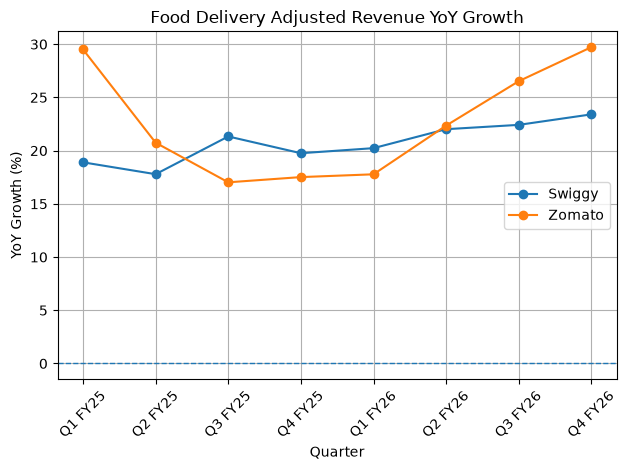

In [19]:
revenue_growth_df = df.dropna(subset=["Adjusted_Revenue_YoY"])

for company in revenue_growth_df["Company"].unique():
    company_data = revenue_growth_df[
        revenue_growth_df["Company"] == company
    ]

    plt.plot(
        company_data["Quarter"],
        company_data["Adjusted_Revenue_YoY"],
        marker="o",
        label=company
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Food Delivery Adjusted Revenue YoY Growth")
plt.xlabel("Quarter")
plt.ylabel("YoY Growth (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
print(
    df.groupby("Company")[[
        "Transaction_Value_YoY",
        "Adjusted_Revenue_YoY"
    ]].corr()
)

                               Transaction_Value_YoY  Adjusted_Revenue_YoY
Company                                                                   
Swiggy  Transaction_Value_YoY               1.000000              0.941154
        Adjusted_Revenue_YoY                0.941154              1.000000
Zomato  Transaction_Value_YoY               1.000000              0.439013
        Adjusted_Revenue_YoY                0.439013              1.000000


Swiggy shows a very strong positive association between transaction-value growth and adjusted-revenue growth (r = 0.94), while Zomato shows a weaker positive association (r = 0.44).

## Business Question 6: Revenue Efficiency

In [21]:
df["Revenue_Rate"] = (
    df["Adjusted_Revenue"] / df["Transaction_Value"] * 100
)

In [22]:
df[
    ["Company", "Quarter", "Transaction_Value",
     "Adjusted_Revenue", "Revenue_Rate"]
]

,Company,Quarter,Transaction_Value,Adjusted_Revenue,Revenue_Rate
0,Swiggy,Q1 FY24,5959,1455,24.416848
1,Swiggy,Q2 FY24,6275,1535,24.462151
2,Swiggy,Q3 FY24,6238,1533,24.575184
3,Swiggy,Q4 FY24,6246,1559,24.959974
4,Swiggy,Q1 FY25,6808,1730,25.411281
5,Swiggy,Q2 FY25,7191,1808,25.142539
6,Swiggy,Q3 FY25,7436,1860,25.013448
7,Swiggy,Q4 FY25,7347,1867,25.411733
8,Swiggy,Q1 FY26,8086,2080,25.723473
9,Swiggy,Q2 FY26,8542,2206,25.825334


In [23]:
df.groupby("Company")["Revenue_Rate"].agg(
    ["mean", "min", "max", "std"]
)

,mean,min,max,std
Company,,,,
Swiggy,25.161961,24.416848,25.825334,0.483963
Zomato,26.826301,23.804318,32.028287,3.292567


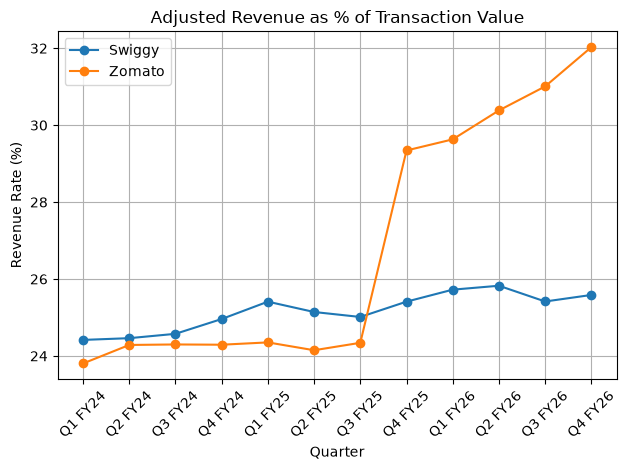

In [24]:
for company in df["Company"].unique():
    company_data = df[df["Company"] == company]

    plt.plot(
        company_data["Quarter"],
        company_data["Revenue_Rate"],
        marker="o",
        label=company
    )

plt.title("Adjusted Revenue as % of Transaction Value")
plt.xlabel("Quarter")
plt.ylabel("Revenue Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Business Question 7: Adjusted EBITDA Margin

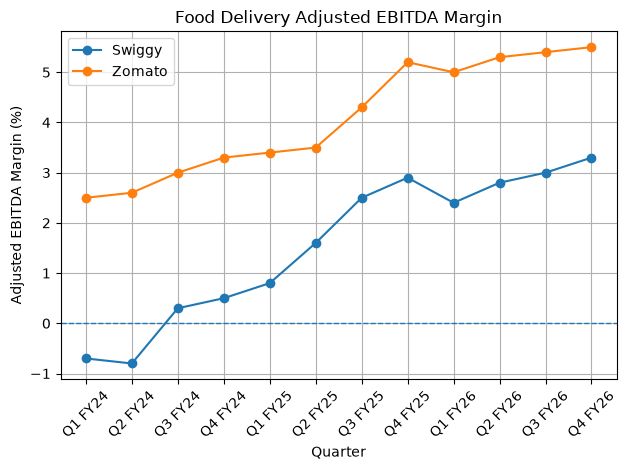

In [25]:
for company in df["Company"].unique():
    company_data = df[df["Company"] == company]

    plt.plot(
        company_data["Quarter"],
        company_data["Adjusted_EBITDA_Margin"],
        marker="o",
        label=company
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Food Delivery Adjusted EBITDA Margin")
plt.xlabel("Quarter")
plt.ylabel("Adjusted EBITDA Margin (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
for company in df["Company"].unique():
    company_data = df[df["Company"] == company]

    start = company_data.iloc[0]["Adjusted_EBITDA_Margin"]
    end = company_data.iloc[-1]["Adjusted_EBITDA_Margin"]

    print(
        company,
        "Start:", start,
        "End:", end,
        "Change:", end - start
    )

Swiggy Start: -0.7 End: 3.3 Change: 4.0
Zomato Start: 2.5 End: 5.5 Change: 3.0


Zomato maintained a higher Food Delivery EBITDA margin throughout the period, while Swiggy achieved a larger improvement in profitability, moving from negative to positive margins.

# ***Intergrating Google Trends

In [30]:
trends_df = pd.read_csv(
    "../data/raw/google_trends_raw.csv",
    parse_dates=["Time"]
)

In [31]:
trends_df.head()
trends_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Time    61 non-null     datetime64[us]
 1   Zomato  61 non-null     int64         
 2   Swiggy  61 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 1.6 KB


In [32]:
trends_df = trends_df.set_index("Time")

In [33]:
quarterly_trends = trends_df.resample("QE").mean()

In [34]:
def get_fy_quarter(date):
    if date.month in [4, 5, 6]:
        return "Q1"
    elif date.month in [7, 8, 9]:
        return "Q2"
    elif date.month in [10, 11, 12]:
        return "Q3"
    else:
        return "Q4"

In [35]:
trends_df["FY_Quarter"] = trends_df.index.map(get_fy_quarter)

In [36]:
trends_df["FY"] = trends_df.index.year + (
    trends_df.index.month >= 4
).astype(int)

In [37]:
trends_df["Quarter"] = (
    trends_df["FY_Quarter"] + 
    " FY" + 
    trends_df["FY"].astype(str).str[-2:]
)

In [38]:
quarterly_trends = (
    trends_df
    .groupby("Quarter")[["Zomato", "Swiggy"]]
    .mean()
    .reset_index()
)

In [39]:
quarterly_trends

,Quarter,Zomato,Swiggy
0,Q1 FY23,68.333333,42.000000
1,Q1 FY24,55.000000,38.333333
2,Q1 FY25,57.000000,42.333333
3,Q1 FY26,48.333333,47.000000
4,Q1 FY27,38.333333,38.666667
5,Q2 FY22,87.500000,40.000000
6,Q2 FY23,77.666667,41.666667
7,Q2 FY24,58.333333,40.666667
8,Q2 FY25,67.333333,48.000000
9,Q2 FY26,45.000000,45.000000


In [40]:
quarter_counts = (
    trends_df
    .groupby("Quarter")
    .size()
    .reset_index(name="Month_Count")
)

quarter_counts

,Quarter,Month_Count
0,Q1 FY23,3
1,Q1 FY24,3
2,Q1 FY25,3
3,Q1 FY26,3
4,Q1 FY27,3
5,Q2 FY22,2
6,Q2 FY23,3
7,Q2 FY24,3
8,Q2 FY25,3
9,Q2 FY26,3


In [41]:
required_quarters = [
    "Q1 FY24", "Q2 FY24", "Q3 FY24", "Q4 FY24",
    "Q1 FY25", "Q2 FY25", "Q3 FY25", "Q4 FY25",
    "Q1 FY26", "Q2 FY26", "Q3 FY26", "Q4 FY26"
]

quarterly_trends = quarterly_trends[
    quarterly_trends["Quarter"].isin(required_quarters)
].copy()

In [42]:
quarterly_trends

,Quarter,Zomato,Swiggy
1,Q1 FY24,55.000000,38.333333
2,Q1 FY25,57.000000,42.333333
3,Q1 FY26,48.333333,47.000000
7,Q2 FY24,58.333333,40.666667
8,Q2 FY25,67.333333,48.000000
9,Q2 FY26,45.000000,45.000000
13,Q3 FY24,57.000000,37.333333
14,Q3 FY25,65.666667,65.000000
15,Q3 FY26,44.333333,45.333333
18,Q4 FY24,59.000000,41.000000


In [43]:
quarterly_trends["Quarter"] = pd.Categorical(
    quarterly_trends["Quarter"],
    categories=required_quarters,
    ordered=True
)

quarterly_trends = quarterly_trends.sort_values("Quarter")

In [44]:
quarterly_trends

,Quarter,Zomato,Swiggy
1,Q1 FY24,55.000000,38.333333
7,Q2 FY24,58.333333,40.666667
13,Q3 FY24,57.000000,37.333333
18,Q4 FY24,59.000000,41.000000
2,Q1 FY25,57.000000,42.333333
8,Q2 FY25,67.333333,48.000000
14,Q3 FY25,65.666667,65.000000
19,Q4 FY25,65.333333,50.000000
3,Q1 FY26,48.333333,47.000000
9,Q2 FY26,45.000000,45.000000


In [45]:
quarterly_trends = quarterly_trends.rename(
    columns={
        "Zomato": "Zomato_Search_Interest",
        "Swiggy": "Swiggy_Search_Interest"
    }
)

In [46]:
print("Shape:", quarterly_trends.shape)
print("\nMissing values:")
print(quarterly_trends.isnull().sum())
print("\nQuarter order:")
print(quarterly_trends["Quarter"].tolist())

Shape: (12, 3)

Missing values:
Quarter                   0
Zomato_Search_Interest    0
Swiggy_Search_Interest    0
dtype: int64

Quarter order:
['Q1 FY24', 'Q2 FY24', 'Q3 FY24', 'Q4 FY24', 'Q1 FY25', 'Q2 FY25', 'Q3 FY25', 'Q4 FY25', 'Q1 FY26', 'Q2 FY26', 'Q3 FY26', 'Q4 FY26']


In [47]:
trends_long = quarterly_trends.melt(
    id_vars="Quarter",
    value_vars=[
        "Zomato_Search_Interest",
        "Swiggy_Search_Interest"
    ],
    var_name="Search_Company",
    value_name="Search_Interest"
)

In [48]:
trends_long["Company"] = (
    trends_long["Search_Company"]
    .str.replace("_Search_Interest", "", regex=False)
)

In [49]:
trends_long.head()

,Quarter,Search_Company,Search_Interest,Company
0,Q1 FY24,Zomato_Search_Interest,55.000000,Zomato
1,Q2 FY24,Zomato_Search_Interest,58.333333,Zomato
2,Q3 FY24,Zomato_Search_Interest,57.000000,Zomato
3,Q4 FY24,Zomato_Search_Interest,59.000000,Zomato
4,Q1 FY25,Zomato_Search_Interest,57.000000,Zomato


In [50]:
trends_long = trends_long[
    ["Quarter", "Company", "Search_Interest"]
]

In [51]:
analysis_df = df.merge(
    trends_long,
    on=["Company", "Quarter"],
    how="left"
)

In [52]:
print("Shape:", analysis_df.shape)

print("\nMissing values:")
print(analysis_df.isnull().sum())

print("\nRows by company:")
print(analysis_df["Company"].value_counts())

print("\nDuplicate Company-Quarter combinations:")
print(
    analysis_df.duplicated(
        subset=["Company", "Quarter"]
    ).sum()
)

Shape: (24, 12)

Missing values:
Company                   0
Quarter                   0
Transaction_Value         0
Adjusted_Revenue          0
MTU                       0
Contribution_Margin       0
Adjusted_EBITDA_Margin    0
Transaction_Value_YoY     8
MTU_YoY                   8
Adjusted_Revenue_YoY      8
Revenue_Rate              0
Search_Interest           0
dtype: int64

Rows by company:
Company
Swiggy    12
Zomato    12
Name: count, dtype: int64

Duplicate Company-Quarter combinations:
0


In [53]:
analysis_df[
    [
        "Company",
        "Quarter",
        "Search_Interest",
        "Transaction_Value",
        "Transaction_Value_YoY",
        "MTU",
        "MTU_YoY",
        "Adjusted_Revenue",
        "Adjusted_Revenue_YoY",
        "Revenue_Rate",
        "Adjusted_EBITDA_Margin"
    ]
]

,Company,Quarter,Search_Interest,Transaction_Value,Transaction_Value_YoY,MTU,MTU_YoY,Adjusted_Revenue,Adjusted_Revenue_YoY,Revenue_Rate,Adjusted_EBITDA_Margin
0,Swiggy,Q1 FY24,38.333333,5959,NaN,12.6,NaN,1455,NaN,24.416848,-0.7
1,Swiggy,Q2 FY24,40.666667,6275,NaN,12.9,NaN,1535,NaN,24.462151,-0.8
2,Swiggy,Q3 FY24,37.333333,6238,NaN,12.5,NaN,1533,NaN,24.575184,0.3
3,Swiggy,Q4 FY24,41.000000,6246,NaN,12.9,NaN,1559,NaN,24.959974,0.5
4,Swiggy,Q1 FY25,42.333333,6808,14.247357,14.0,11.111111,1730,18.900344,25.411281,0.8
5,Swiggy,Q2 FY25,48.000000,7191,14.597610,14.7,13.953488,1808,17.785016,25.142539,1.6
6,Swiggy,Q3 FY25,65.000000,7436,19.204873,14.9,19.200000,1860,21.330724,25.013448,2.5
7,Swiggy,Q4 FY25,50.000000,7347,17.627281,15.1,17.054264,1867,19.756254,25.411733,2.9
8,Swiggy,Q1 FY26,47.000000,8086,18.772033,16.3,16.428571,2080,20.231214,25.723473,2.4
9,Swiggy,Q2 FY26,45.000000,8542,18.787373,17.2,17.006803,2206,22.013274,25.825334,2.8
